In [96]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder,StandardScaler
from xgboost import XGBRegressor
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df=pd.read_csv('/content/Zillow.csv')
df.sample(6)

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,target
42411,10791515,NaN,NaN,NaN,2.0,3.0,NaN,8.0,2.0,NaN,NaN,1907.0,1907.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,34178820.0,-118608289.0,7528.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LARS,6.037137e+07,12447.0,3101.0,48570.0,96389.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1960.0,NaN,NaN,79213.0,107356.0,2016.0,28143.0,1440.38,NaN,NaN,6.037137e+13,0.072372
53331,14387894,NaN,NaN,NaN,2.5,3.0,NaN,NaN,2.5,NaN,NaN,2074.0,2074.0,NaN,NaN,NaN,NaN,6059.0,2.0,2.0,2.0,485.0,NaN,NaN,33586641.0,-117698479.0,5000.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059042e+07,25458.0,1286.0,NaN,96971.0,7.0,NaN,1.0,NaN,NaN,NaN,NaN,1978.0,2.0,NaN,211302.0,512318.0,2016.0,301016.0,5225.40,NaN,NaN,6.059042e+13,-0.029320
58746,11062555,1.0,NaN,NaN,3.0,4.0,NaN,7.0,3.0,NaN,NaN,2278.0,2278.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34227688.0,-118507017.0,19384.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LARA,6.037115e+07,12447.0,3101.0,33183.0,96355.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1986.0,NaN,NaN,220010.0,345433.0,2016.0,125423.0,4308.72,NaN,NaN,6.037115e+13,-0.011801
2852,12102711,1.0,NaN,NaN,2.0,1.0,NaN,6.0,2.0,NaN,NaN,882.0,882.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,34137100.0,-118145000.0,32947.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,PSR3,6.037464e+07,47019.0,3101.0,275405.0,96289.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1973.0,NaN,NaN,117067.0,146320.0,2016.0,29253.0,1848.96,NaN,NaN,6.037464e+13,0.000828
23915,14613164,NaN,NaN,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,975.0,975.0,NaN,NaN,NaN,NaN,6059.0,NaN,1.0,1.0,0.0,NaN,NaN,33624500.0,-117934000.0,NaN,NaN,NaN,NaN,NaN,NaN,34,266.0,NaN,6.059064e+07,53571.0,1286.0,NaN,96981.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1989.0,NaN,NaN,122324.0,426405.0,2016.0,304081.0,4818.66,NaN,NaN,6.059064e+13,0.002044
5006,12273288,NaN,NaN,NaN,2.0,3.0,NaN,6.0,2.0,NaN,NaN,1264.0,1264.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,7.0,33909382.0,-118236533.0,4999.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,CORL*,6.037541e+07,24174.0,3101.0,NaN,96092.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1947.0,NaN,NaN,30618.0,50893.0,2016.0,20275.0,1430.55,NaN,NaN,6.037541e+13,0.010609


In [98]:
df.shape

(77613, 59)

In [99]:
#data cleaning
to_remove=[]
for col in df.columns:
  if df[col].nunique==1:
    to_remove.append(col)
  elif (df[col].isnull()).mean()>0.6:
    to_remove.append(col)
print(len(to_remove))

29


In [100]:
df.drop(to_remove,axis=1,inplace=True)

In [101]:
df.isnull().sum()

,0
parcelid,0
bathroomcnt,34
bedroomcnt,34
buildingqualitytypeid,27804
calculatedbathnbr,650
calculatedfinishedsquarefeet,235
finishedsquarefeet12,3690
fips,34
fullbathcnt,650
heatingorsystemtypeid,28042


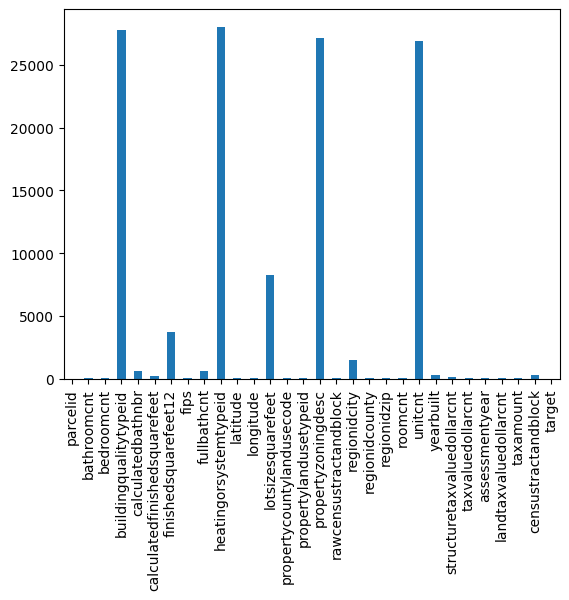

In [102]:
df.isnull().sum().plot.bar()
plt.show(
)

In [103]:
#Imputation
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  else:
    df[col]=df[col].fillna(df[col].mean())

In [104]:
df.isnull().sum()

,0
parcelid,0
bathroomcnt,0
bedroomcnt,0
buildingqualitytypeid,0
calculatedbathnbr,0
calculatedfinishedsquarefeet,0
finishedsquarefeet12,0
fips,0
fullbathcnt,0
heatingorsystemtypeid,0


In [105]:
ints,objects,floats=[],[],[]
for col in df.columns:
  if df[col].dtype==float:
    floats.append(col)
  elif df[col].dtype=='object':
    objects.append(col)
  else:
    ints.append(col)

len(floats),len(ints),len(objects)

(27, 1, 2)

In [106]:
for col in objects:
  print(col,df[col].nunique())
  print(df[col].unique())
  print()

propertycountylandusecode 75
['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222' '1310'
 '1120' '0111' '1116' '1421' '0110' '0105' '012E' '0141' '1333' '0115'
 '040V' '010L' '040B' '012D' '0114' '0203' '030G' '0130' '105' '020G'
 '020M' '020E']

propertyzoningdesc 1907
['LAR1' 'LCR110000*' 'LAR3' ... 'HAR4-R2*' 'LCR1VV' 'BFA15000*']



/tmp/ipython-input-337490151.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['target'])


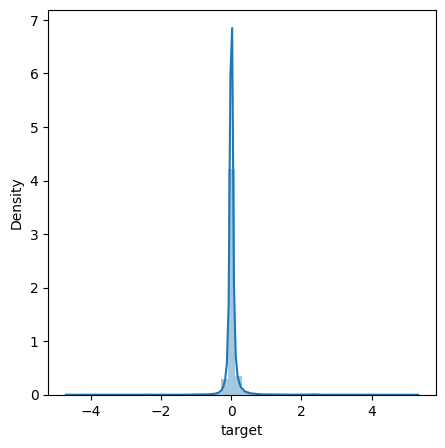

In [107]:
plt.figure(figsize=(5,5))
sns.distplot(df['target'])
plt.show()

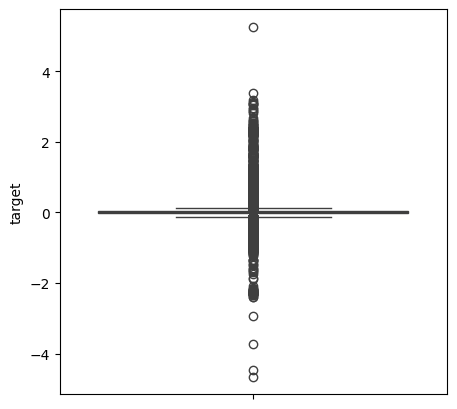

In [108]:
plt.figure(figsize=(5,5))
sns.boxplot(df['target'])
plt.show()

In [109]:
print(f'shape before outlier removal: {df.shape}')
df=df[(df['target'] >-1)&(df['target']<1)]
print(f'shape after outlier removal: {df.shape}')

shape before outlier removal: (77613, 30)
shape after outlier removal: (77261, 30)


In [110]:
for col in objects:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])

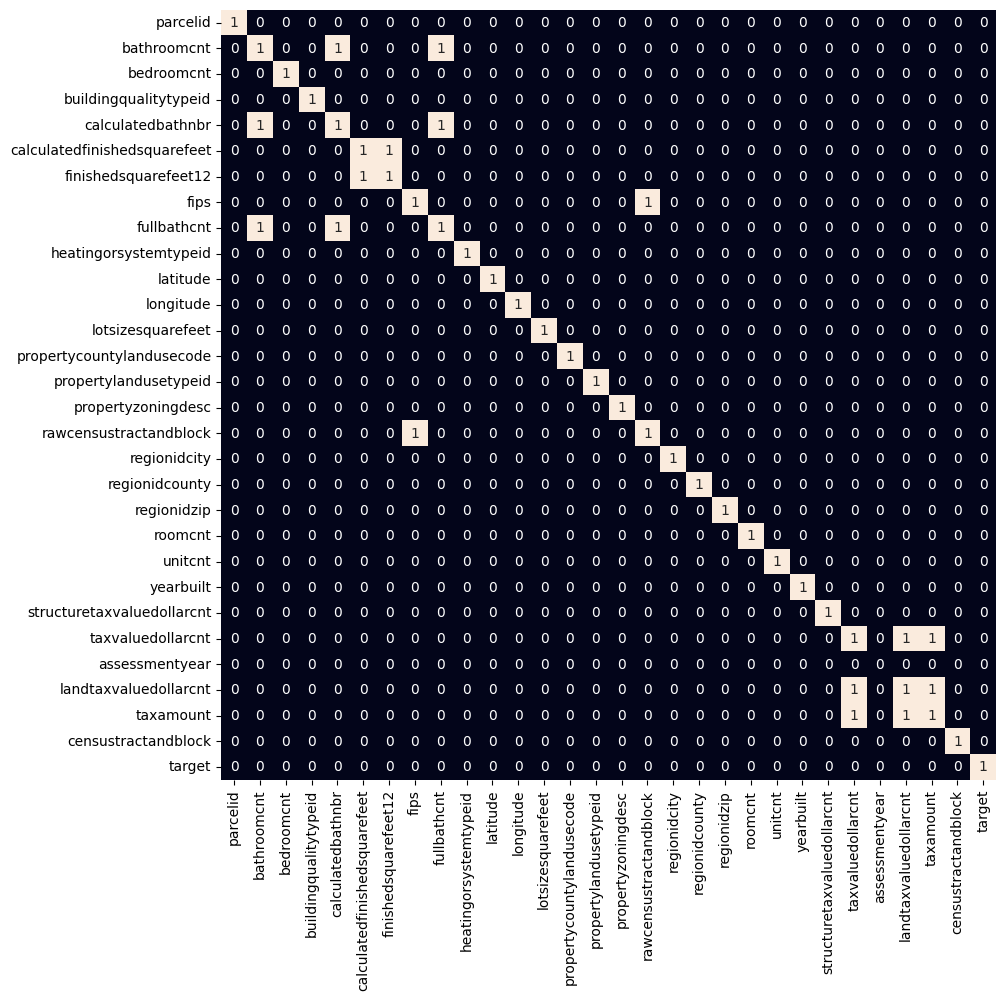

In [111]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr()>0.8,annot=True,cbar=False)
plt.show()

In [112]:
to_remove=['calculatedbathnbr','fullbathcnt','fips',
           'rawcensustractandblock','taxvaluedollarcnt',
           'finishedsquarefeet12','landtaxvaluedollarcnt']

df.drop(to_remove,axis=1,inplace=True)

In [113]:
features=df.drop(['parcelid'],axis=1)
target=df['target']

In [114]:
split_index=int(len(df)*0.8)

In [115]:
X_train=features.iloc[:split_index]
X_test=features.iloc[split_index:]
y_train=target.iloc[:split_index]
y_test=target.iloc[split_index:]

In [116]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((61808, 22), (15453, 22), (61808,), (15453,))

In [117]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [118]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score as r2

In [119]:
models=[LinearRegression(),XGBRegressor(),
        Lasso(),RandomForestRegressor(),Ridge()]

In [121]:
for i in range(5):
  models[i].fit(X_train,y_train)
  print(f'{models[i]}: ')

  train_preds=models[i].predict(X_train)
  print('=======================')
  print('    Traning Error')
  print('=======================')
  print("Mean Absolute Error: ",mae(y_train,train_preds))
  print("Mean squared Error: ",mse(y_train,train_preds))
  print("Root mean squared Error: ",np.sqrt(mse(y_train,train_preds)))
  print("R2 Score: ",r2(y_train,train_preds))
  print()

  test_preds=models[i].predict(X_test)
  print('=======================')
  print('    Testing Error')
  print('=======================')
  print("Mean Absolute Error: ",mae(y_train,train_preds))
  print("Mean squared Error: ",mse(y_train,train_preds))
  print("Root mean squared Error: ",np.sqrt(mse(y_train,train_preds)))
  print("R2 Score: ",r2(y_train,train_preds))

LinearRegression(): 
    Traning Error
Mean Absolute Error:  1.0270728101285075e-16
Mean squared Error:  2.4521079131650817e-32
Root mean squared Error:  1.5659207876406398e-16
R2 Score:  1.0

    Testing Error
Mean Absolute Error:  1.0270728101285075e-16
Mean squared Error:  2.4521079131650817e-32
Root mean squared Error:  1.5659207876406398e-16
R2 Score:  1.0
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone